## Nombre: Nathaly Bravo
## 06/07/2026
## Métodos Númericos - TAREA 07 



##### 1) Dados los puntos (0,1),(1,5),(2,3), determine el spline cúbico. 

Ecuaciones:
 1. $~ a_0 = 1$ <br> <br>
 2. $~a_0 +b_0 +c_0 +d_0 = 5$ <br> <br>
 3. $~a_1 = 5$ <br> <br>
 4. $~a_1 + b_1 + c_1 +d_1 = 3$ <br> <br>
 5. $ ~b_0 + 2c_0 + 3d_0 = b1$<br> <br>
 6. $~ c_0 + 3d_0 = c_1$<br> <br>
 7. $~c_0 = 0$<br> <br>
 8. $~ c_1 + 3d_1 = 0$<br> <br>
 Resultado de los splines cúbicos:
 $$S_0 (x) = 1+5.5x - \frac{6}{4}x^3$$
 $$S_1 (x) = 5 + (x-1) - 4.5(x-1)^2 + \frac{6}{4}(x-1)^3$$

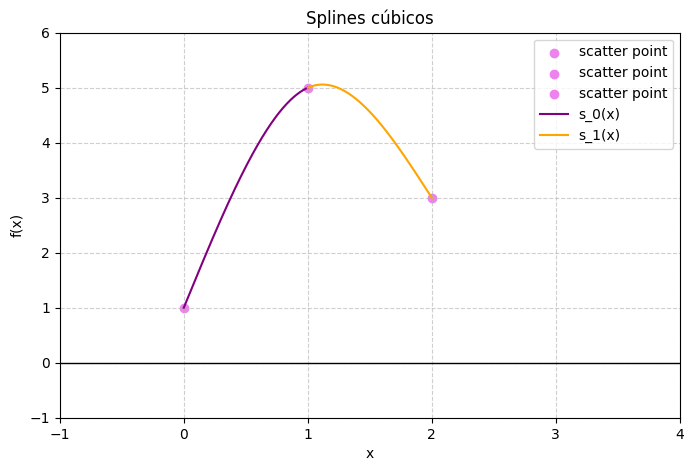

In [4]:
import numpy as np
import matplotlib.pyplot as plt
x0,y0 = 0,1
x1, y1= 1,5
x2, y2= 2,3

xs0 = np.linspace(0, 1, 200)
xs1 = np.linspace(1, 2, 200)
a0= 1
a1= 5
b0= 5.5
b1= 1
c0= 0 
c1= -4.5 
d0= -6/4
d1= 6/4

def s_0(x):
    return a0 + b0 * (x-x0) - c0 * (x - x0) **2 + d0 * (x - x0) **3

def s_1(x):
    return a1 + b1 * (x - x1) + c1 * (x - x1) ** 2 + d1 * (x - x1) ** 3


plt.figure(figsize=(8, 5))
plt.scatter([0.0], [1.0], color='violet', label='scatter point')
plt.scatter([1.0], [5.0], color='violet', label='scatter point')
plt.scatter([2.0], [3.0], color='violet', label='scatter point')
plt.plot(xs0, s_0(xs0), label='s_0(x)', color='purple')
plt.plot(xs1, s_1(xs1), label='s_1(x)', color='orange')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Splines cúbicos')
plt.legend()
plt.xlim(-1, 4)
plt.ylim(-1, 6)
plt.show()

#### 2) Dados los puntos (−1,1),(1,3), determine el spline cúbico sabiendo que 𝑓′(𝑥0)=1,𝑓′(𝑥𝑛)=2.

Ecuaciones:

1. $~ a_0 = 1$ <br> <br>
2. $~a_0 +2b_0 +4c_0 +8d_0 = 3$ <br> <br>
3. $~b_0 = 1$ <br> <br>
4. $~b_0 + 4c_0 +12d_0 = 2$ <br> <br>
 Resultando de los splines cúbicos:
 $$S_0 (x) = 1+(x+1) - \frac{1}{2}(x+1)^2 - \frac{1}{4}(x+1)^3$$

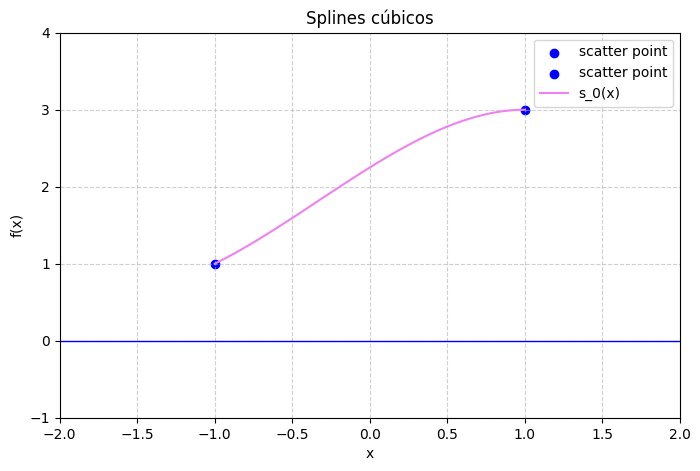

In [15]:
import numpy as np
import matplotlib.pyplot as plt

x0,y0 = -1,1
x1, y1= 1,3

xs0 = np.linspace(-1, 1, 200)
a0= 1
b0= 1
c0= -1/2 
d0= -1/4

def s_0(x):
    return a0 + b0 * (x-x0) - c0 * (x - x0) **2 + d0 * (x - x0) **3

plt.figure(figsize=(8, 5))
plt.scatter([-1.0], [1.0], color='blue', label='scatter point')
plt.scatter([1.0], [3.0], color='blue', label='scatter point')
plt.plot(xs0, s_0(xs0), label='s_0(x)', color='violet')
plt.axhline(0, color='blue', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Splines cúbicos')
plt.legend()
plt.xlim(-2, 2)
plt.ylim(-1, 4)
plt.show()

#### 3) Diríjase al pseudocódigo del spline cúbico con frontera natural provisto en clase, en base a ese pseudocódigo complete la siguiente función: 
 



In [8]:
import sympy as sym
from IPython.display import display


# ##################################################################
def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:
    """
    Cubic spline interpolation `S`. Every two points are interpolated by a cubic polynomial
    `S_j` of the form `S_j(x) = a_j + b_j(x - x_j) + c_j(x - x_j)^2 + d_j(x - x_j)^3.`

    xs must be different  but not necessarily ordered nor equally spaced.

    ## Parameters
    - xs, ys: points to be interpolated

    ## Return
    - List of symbolic expressions for the cubic spline interpolation.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])  # sort points by x

    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1  # number of splines

    h = [xs[i + 1] - xs[i] for i in range(n)]  # distances between contiguous xs

    alpha = [0] * n
    for i in range(1, n):
        alpha[i] = 3 / h[i] * (ys[i + 1] - ys[i]) - 3 / h[i - 1] * (ys[i] - ys[i - 1])

    l = [1]
    u = [0]
    z = [0]

    for i in range(1, n):
        l += [2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1]]
        u += [h[i] / l[i]]
        z += [(alpha[i] - h[i - 1] * z[i - 1]) / l[i]]

    l.append(1)
    z.append(0)
    c = [0] * (n + 1)

    x = sym.Symbol("x")
    splines = []
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d = (c[j + 1] - c[j]) / (3 * h[j])
        a = ys[j]
        S = a + b*(x - xs[j]) + c[j]*(x - xs[j])**2 + d*(x - xs[j])**3

        print(j, a, b, c[j], d)
        splines.append(S)

    splines.reverse()
    return splines

##### 4) Usando la función anterior, encuentre el spline cúbico para

$$xs = [1,2,3]$$
$$yx = [2,3,5]$$

In [22]:
xs = [1, 2, 3]
ys = [2, 3, 5]

splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]
print("-----------")
print("-----------")
_ = [display(s.expand()) for s in splines]

1 3 1.5 0.75 -0.25
0 2 0.75 0.0 0.25


0.75*x + 0.25*(x - 1)**3 + 1.25

1.5*x - 0.25*(x - 2)**3 + 0.75*(x - 2)**2

-----------
-----------


0.25*x**3 - 0.75*x**2 + 1.5*x + 1.0

-0.25*x**3 + 2.25*x**2 - 4.5*x + 5.0

##### 5. Usando la función anterior, encuentre el spline cúbico para:


$$xs = [0,1,2,3]$$
$$yx = [-1,1,5,2]$$

In [23]:
xs = [0,1, 2, 3]
ys = [-1,1,5,2]

splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]
print("-----------")
print("-----------")
_ = [display(s.expand()) for s in splines]

2 5 1.0 -6.0 2.0
1 1 4.0 3.0 -3.0
0 -1 1.0 0.0 1.0


1.0*x**3 + 1.0*x - 1

4.0*x - 3.0*(x - 1)**3 + 3.0*(x - 1)**2 - 3.0

1.0*x + 2.0*(x - 2)**3 - 6.0*(x - 2)**2 + 3.0

-----------
-----------


1.0*x**3 + 1.0*x - 1

-3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0

2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0

##### 6)  Use la función cubic_spline_clamped, provista en el enlace de Github, para graficar los datos de la siguiente tabla

In [12]:
def cubic_spline_clamped(xs: list[float], ys: list[float], B0: float, B1: float) -> list[sym.Symbol]:
    """
    Cubic spline interpolation with clamped boundary conditions.
    S'_0(x0) = B0
    S'_{n-1}(xn) = B1

    Returns symbolic expressions for each cubic polynomial.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])  
    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1  # number of splines
    h = [xs[i + 1] - xs[i] for i in range(n)]

    
    alpha = [0] * (n + 1)

   
    alpha[0] = 3 * ((ys[1] - ys[0]) / h[0] - B0)

    # Interior points
    for i in range(1, n):
        alpha[i] = 3 * ((ys[i + 1] - ys[i]) / h[i] - (ys[i] - ys[i - 1]) / h[i - 1])

    # Last boundary
    alpha[n] = 3 * (B1 - (ys[n] - ys[n - 1]) / h[n - 1])

    
    l = [2 * h[0]]
    u = [h[0] / l[0]]
    z = [alpha[0] / l[0]]

    for i in range(1, n):
        l.append(2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1])
        u.append(h[i] / l[i])
        z.append((alpha[i] - h[i - 1] * z[i - 1]) / l[i])

    l.append(2 * h[n - 1] - h[n - 1] * u[n - 1])
    z.append((alpha[n] - h[n - 1] * z[n - 1]) / l[n])

    c = [0] * (n + 1)
    b = [0] * n
    d = [0] * n

  
    c[n] = z[n]

    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b[j] = ((ys[j + 1] - ys[j]) / h[j]
                - h[j] * (c[j + 1] + 2 * c[j]) / 3)
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])

   
    x = sym.Symbol("x")
    splines = []

    for j in range(n):
        a = ys[j]
        S = a + b[j] * (x - xs[j]) + c[j] * (x - xs[j])**2 + d[j] * (x - xs[j])**3
        print(f"S_{j}(x): a={a}, b={b[j]}, c={c[j]}, d={d[j]}")
        splines.append(S)

    return splines

In [21]:
print("Resultados Finales\n")

xs = [0, 1, 2, 3]
ys = [-1, 1, 5, 2]


B0 = 3     
B1 = -4    

splines = cubic_spline_clamped(xs, ys, B0, B1)

for s in splines:
    display(s)
print("------")
print("------")
for s in splines:
    display(s.expand())


Resultados Finales

S_0(x): a=-1, b=3.0, c=-3.533333333333333, d=2.533333333333333
S_1(x): a=1, b=3.5333333333333337, c=4.066666666666666, d=-3.6
S_2(x): a=5, b=0.8666666666666667, c=-6.733333333333333, d=2.8666666666666667


2.53333333333333*x**3 - 3.53333333333333*x**2 + 3.0*x - 1

3.53333333333333*x - 3.6*(x - 1)**3 + 4.06666666666667*(x - 1)**2 - 2.53333333333333

0.866666666666667*x + 2.86666666666667*(x - 2)**3 - 6.73333333333333*(x - 2)**2 + 3.26666666666667

------
------


2.53333333333333*x**3 - 3.53333333333333*x**2 + 3.0*x - 1

-3.6*x**3 + 14.8666666666667*x**2 - 15.4*x + 5.13333333333333

2.86666666666667*x**3 - 23.9333333333333*x**2 + 62.2*x - 46.6

CURVA 1

=====RESULTADOS=====
S_0(x): a=3.0, b=1.0, c=-0.3468099653460706, d=0.046809965346070785
S_1(x): a=3.7, b=0.4468099653460711, c=-0.20638006930785827, d=0.02655521213824114
S_2(x): a=3.9, b=-0.07447972276856785, c=0.03261683993631198, d=0.3418628828322561
S_3(x): a=4.2, b=1.0163426056008245, c=1.0582054884330803, d=-0.5745480940339047
S_4(x): a=5.7, b=1.4091093003652708, c=-0.665438793668634, d=0.15632949330336265
S_5(x): a=6.6, b=0.5472201929380909, c=-0.19645031375854607, d=0.023920108644750342
S_6(x): a=7.1, b=0.04846024164091059, c=-0.05292966189004403, d=-0.0025560654782346287
S_7(x): a=6.7, b=-0.3381314976116887, c=-0.07593425119415569, d=0.005741781399269462

Polinomios expandidos:
S_0(x) = 0.0468099653460708*x**3 - 0.487239861384283*x**2 + 1.83404982673035*x + 1.60638006930786
S_1(x) = 0.0265552121382411*x**3 - 0.365711342137305*x**2 + 1.5909927882364*x + 1.7684180949705
S_2(x) = 0.341862882832256*x**3 - 5.09532640254753*x**2 + 25.2390680902875*x - 37.6450407417814
S_3(

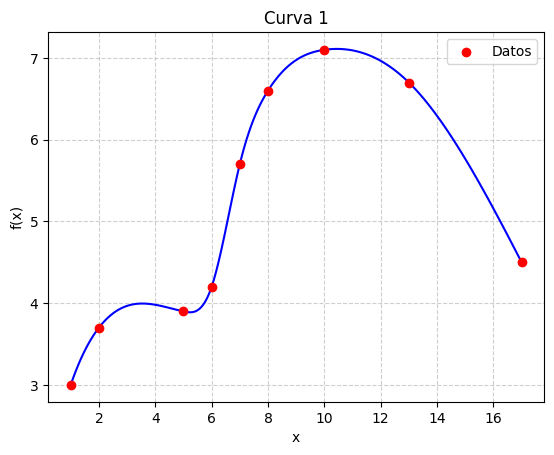

CURVA 2

=====RESULTADOS=====
S_0(x): a=4.5, b=3.0, c=-1.1007084510629728, d=0.12616207628025017
S_1(x): a=7.0, b=-0.19787464681108174, c=0.03475023545927881, d=-0.022930673285194974
S_2(x): a=6.1, b=-0.6085014127556733, c=-0.17162582410747595, d=0.2801272368631492
S_3(x): a=5.6, b=-0.11137135038117751, c=0.6687558864819717, d=-0.35738453610079396
S_4(x): a=5.8, b=0.1539868142803838, c=-0.4033977218204103, d=0.08820215734010924
S_5(x): a=5.2, b=-0.4011781849199465, c=0.1258152222202451, d=-2.568002126658778

Polinomios expandidos:
S_0(x) = 0.12616207628025*x**3 - 7.53497434135573*x**2 + 149.806607471118*x - 984.439023122068
S_1(x) = -0.022930673285195*x**3 + 1.41059063257098*x**2 - 29.1046920074162*x + 208.302973401493
S_2(x) = 0.280127236863149*x**3 - 19.5004051676648*x**2 + 451.848211398006*x - 3479.00261937341
S_3(x) = -0.357384536100794*x**3 + 26.4004424857391*x**2 - 649.772132283688*x + 5333.96013008014
S_4(x) = 0.0882021573401092*x**3 - 7.0185595223286*x**2 + 185.702917918006*x -

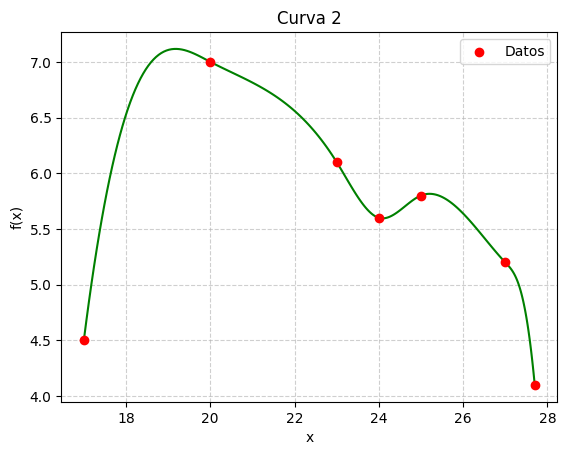

CURVA 3

=====RESULTADOS=====
S_0(x): a=4.1, b=0.33, c=2.262046204620452, d=-3.7994132746607767
S_1(x): a=4.3, b=0.6613861386138599, c=-1.1574257425742553, d=0.29603960396039536
S_2(x): a=4.1, b=-0.7653465346534649, c=-0.2693069306930693, d=-0.06534653465346552

Polinomios expandidos:
S_0(x) = -3.79941327466078*x**3 + 317.993289328931*x**2 - 8870.74279427937*x + 82483.079611294
S_1(x) = 0.296039603960395*x**3 - 26.0247524752475*x**2 + 761.762376237622*x - 7420.301980198
S_2(x) = -0.0653465346534655*x**3 + 5.41584158415843*x**2 - 150.014851485149*x + 1393.54455445545


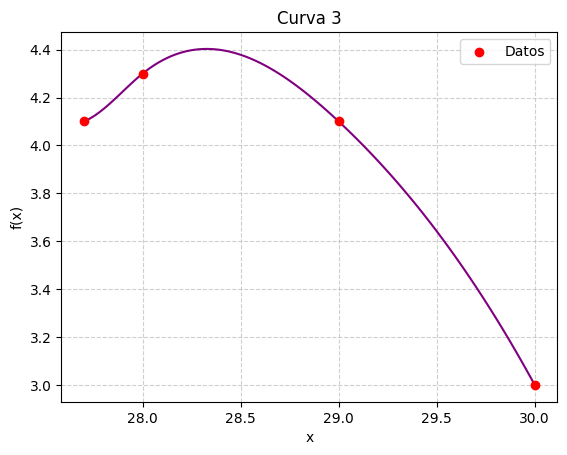

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym

def cubic_spline_clamped(xs, ys, B0, B1):
    points = sorted(zip(xs, ys), key=lambda p: p[0])
    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1
    h = [xs[i + 1] - xs[i] for i in range(n)]

    alpha = [0] * (n + 1)
    alpha[0] = 3 * ((ys[1] - ys[0]) / h[0] - B0)
    for i in range(1, n):
        alpha[i] = 3 * ((ys[i + 1] - ys[i]) / h[i] - (ys[i] - ys[i - 1]) / h[i - 1])
    alpha[n] = 3 * (B1 - (ys[n] - ys[n - 1]) / h[n - 1])

    l = [2 * h[0]]
    u = [h[0] / l[0]]
    z = [alpha[0] / l[0]]
    for i in range(1, n):
        l.append(2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1])
        u.append(h[i] / l[i])
        z.append((alpha[i] - h[i - 1] * z[i - 1]) / l[i])
    l.append(2 * h[n - 1] - h[n - 1] * u[n - 1])
    z.append((alpha[n] - h[n - 1] * z[n - 1]) / l[n])

    c = [0] * (n + 1)
    b = [0] * n
    d = [0] * n
    c[n] = z[n]
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b[j] = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])

    x = sym.Symbol("x")
    splines = []
    for j in range(n):
        a = ys[j]
        S = a + b[j] * (x - xs[j]) + c[j] * (x - xs[j])**2 + d[j] * (x - xs[j])**3
        print(f"S_{j}(x): a={a}, b={b[j]}, c={c[j]}, d={d[j]}")
        splines.append(S)

    return splines, xs


def graficar_spline(xs, ys, B0, B1, titulo, color):
    
    print(f"\n=====RESULTADOS=====")
    splines, xs_ord = cubic_spline_clamped(xs, ys, B0, B1)
    x = sym.Symbol("x")

    print("\nPolinomios expandidos:")
    for j, s in enumerate(splines):
        print(f"S_{j}(x) =", s.expand())

    plt.scatter(xs, ys, color='red', zorder=5, label='Datos')
    for j in range(len(splines)):
        f = sym.lambdify(x, splines[j], "numpy")
        xj = np.linspace(xs_ord[j], xs_ord[j + 1], 50)
        plt.plot(xj, f(xj), color=color)

    plt.title(titulo)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

print("CURVA 1")

x1 = [1, 2, 5, 6, 7, 8, 10, 13, 17]
y1 = [3.0, 3.7, 3.9, 4.2, 5.7, 6.6, 7.1, 6.7, 4.5]
graficar_spline(x1, y1, 1.0, -0.67, "Curva 1", "blue")
plt.show()

print("CURVA 2")
x2 = [17, 20, 23, 24, 25, 27, 27.7]
y2 = [4.5, 7.0, 6.1, 5.6, 5.8, 5.2, 4.1]
graficar_spline(x2, y2, 3.0, -4.0, "Curva 2", "green")
plt.show()

print("CURVA 3")
x3 = [27.7, 28, 29, 30]
y3 = [4.1, 4.3, 4.1, 3.0]
graficar_spline(x3, y3, 0.33, -1.5, "Curva 3", "purple")
plt.show()